In [1]:
from torchvggish import vggish
import torch
from easydict import EasyDict as edict
class audio_extractor(torch.nn.Module):
    def __init__(self, cfg, device):
        super(audio_extractor, self).__init__()
        self.audio_backbone = vggish.VGGish(cfg, device)

    def forward(self, audio):
        audio_fea = self.audio_backbone(audio)
        return audio_fea
class Config:
    def __init__(self) -> None:
        pass
    def device(self):
        device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
        return device
    def config(self):
        cfg = edict()
        cfg.BATCH_SIZE = 4 # default 4
        cfg.LAMBDA_1 = 0.5 # default: 0.5
        cfg.MASK_NUM = 10 # 10 for fully supervised
        cfg.NUM_CLASSES = 71 # 70 + 1 background

        cfg.TRAIN = edict()

        cfg.TRAIN.FREEZE_AUDIO_EXTRACTOR = True
        cfg.TRAIN.PRETRAINED_VGGISH_MODEL_PATH = "./torchvggish/vggish-10086976.pth"
        cfg.TRAIN.PREPROCESS_AUDIO_TO_LOG_MEL = True #! notice
        cfg.TRAIN.POSTPROCESS_LOG_MEL_WITH_PCA = False
        cfg.TRAIN.PRETRAINED_PCA_PARAMS_PATH = "./torchvggish/vggish_pca_params-970ea276.pth"
        cfg = edict()
        cfg.BATCH_SIZE = 4 # default 4
        cfg.LAMBDA_1 = 0.5 # default: 0.5
        cfg.MASK_NUM = 10 # 10 for fully supervised
        cfg.NUM_CLASSES = 71 # 70 + 1 background

        ###############################
        # TRAIN
        cfg.TRAIN = edict()

        cfg.TRAIN.FREEZE_AUDIO_EXTRACTOR = True
        cfg.TRAIN.PRETRAINED_VGGISH_MODEL_PATH = "./torchvggish/vggish-10086976.pth"
        cfg.TRAIN.PREPROCESS_AUDIO_TO_LOG_MEL = True #! notice
        cfg.TRAIN.POSTPROCESS_LOG_MEL_WITH_PCA = False
        cfg.TRAIN.PRETRAINED_PCA_PARAMS_PATH = "./torchvggish/vggish_pca_params-970ea276.pth"
        cfg.TRAIN.FREEZE_VISUAL_EXTRACTOR = True
        cfg.TRAIN.PRETRAINED_RESNET50_PATH = "../../pretrained_backbones/resnet50-19c8e357.pth"
        cfg.TRAIN.PRETRAINED_PVTV2_PATH = "../../pretrained_backbones/pvt_v2_b5.pth"

        cfg.TRAIN.FINE_TUNE_SSSS = False
        cfg.TRAIN.PRETRAINED_S4_AVS_WO_TPAVI_PATH = "../single_source_scripts/logs/ssss_20220118-111301/checkpoints/checkpoint_29.pth.tar"
        cfg.TRAIN.PRETRAINED_S4_AVS_WITH_TPAVI_PATH = "../single_source_scripts/logs/ssss_20220118-112809/checkpoints/checkpoint_68.pth.tar"

        ###############################
        # DATA
        cfg.DATA = edict()
        cfg.DATA.CROP_IMG_AND_MASK = True
        cfg.DATA.CROP_SIZE = 224 # short edge

        cfg.DATA.META_CSV_PATH = "./avs_released/metadata.csv" #! notice: you need to change the path
        cfg.DATA.LABEL_IDX_PATH = "./avs_released/label2idx.json" #! notice: you need to change the path

        cfg.DATA.DIR_BASE = "./avs_released" #! notice: you need to change the path
        cfg.DATA.DIR_MASK = "../../avsbench_data/v2_data/gt_masks" #! notice: you need to change the path
        cfg.DATA.DIR_COLOR_MASK = "../../avsbench_data/v2_data/gt_color_masks_rgb" #! notice: you need to change the path
        cfg.DATA.IMG_SIZE = (224, 224)
        ###############################
        cfg.DATA.RESIZE_PRED_MASK = True
        cfg.DATA.SAVE_PRED_MASK_IMG_SIZE = (360, 240) # (width, height)
        return cfg

In [2]:
config_ = Config()
vggish = audio_extractor(config_.config() , config_.device())

In [3]:
import pickle
path = './data/audio_512/offline_episode_audio_1.pkl'
with open( path , 'rb') as file:
    data = pickle.load(file)

In [4]:
audio = data[1]['audio'][0]
audio.shape

(2, 18000)

In [5]:
path = '../res/singing.wav'

In [6]:
import sys
import argparse

sys.argv = ['script_name', '--forward_amount', '0.5']

parser = argparse.ArgumentParser()
parser.add_argument('--forward_amount', type=float, help='前进的距离')

args = parser.parse_args()

from config import config
from env.v0d0 import Env
import torch
import numpy as np
import habitat_sim
from habitat.utils.visualizations import maps
import random
from draw import Draw
config['random_seed'] = 1
env = Env(config)
sim = env._sim
env.reset()

/data/kxy/anaconda3/envs/ss/lib/python3.9/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
2024-12-05 13:22:23.748351: I tensorflow/core/util/port.cc:111] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2024-12-05 13:22:23.788668: E tensorflow/compiler/xla/stream_executor/cuda/cuda_dnn.cc:9342] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
2024-12-05 13:22:23.788709: E tensorflow/compiler/xla/stream_executor/cuda/cuda_fft.cc:609] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2024-12-05 13:22:23.78

[13:22:27:174566]:[Metadata] AttributesManagerBase.h(380)::createFromJsonOrDefaultInternal : <Dataset>: Proposing JSON name : default.scene_dataset_config.jsonsource_poses [array([0.39301765, 0.072447  , 0.14520915], dtype=float32)]
agent 0 reseting
agent 0 initialization retried.
agent_state.position [ 2.4216106  0.072447  -1.3202313]
agent 1 reseting
agent 1 initialization retried.
agent_state.position [1.4090571  0.072447   0.95348984]
 from original name : default| This file does not exist.
[13:22:27:174656]:[Metadata] AssetAttributesManager.cpp(121)::createObject : Asset attributes (capsule3DSolid:capsule3DSolid_hemiRings_4_cylRings_1_segments_12_halfLen_0.75_useTexCoords_false_useTangents_false) created and registered.
[13:22:27:174691]:[Metadata] AssetAttributesManager.cpp(121)::createObject : Asset attributes (capsule3DWireframe:capsule3DWireframe_hemiRings_8_cylRings_1_segments_16_halfLen_1) created and registered.
[13:22:27:174724]:[Metadata] AssetAttributesManager.cpp(121)::

[13:22:27:175597]:[Metadata] SceneDatasetAttributesManager.cpp(308)::readDatasetJSONCell : "stages.default_attributes" set in Attributes Manager from JSON.
[13:22:27:175656]:[Metadata] AttributesManagerBase.h(352)::buildAttrSrcPathsFromJSONAndLoad : Glob path result for ../data/scene_datasets/mp3d/*/*.glb : ../data/scene_datasets/mp3d/17DRP5sb8fy/17DRP5sb8fy.glb
[13:22:27:175743]:[Metadata] SceneInstanceAttributesManager.cpp(65)::setValsFromJSONDoc : No Stage specified for scene default_attributes , or specification error.
[13:22:27:175750]:[Metadata] SceneInstanceAttributesManager.cpp(105)::setValsFromJSONDoc : No Articulated Objects specified for scene default_attributes , or specification error.
[13:22:27:175757]:[Metadata] SceneInstanceAttributesManager.cpp(125)::setValsFromJSONDoc : No navmesh_instance specified for scene default_attributes .
[13:22:27:175763]:[Metadata] SceneInstanceAttributesManager.cpp(135)::setValsFromJSONDoc : No semantic_scene_instance specified for scene de

[{'camera': array([[[111, 103,  75, 255],
          [113, 103,  76, 255],
          [113, 103,  76, 255],
          ...,
          [157, 133,  89, 255],
          [157, 133,  89, 255],
          [155, 134,  91, 255]],
  
         [[108, 101,  73, 255],
          [111, 101,  74, 255],
          [111, 101,  74, 255],
          ...,
          [157, 133,  89, 255],
          [155, 134,  91, 255],
          [155, 134,  91, 255]],
  
         [[108, 101,  73, 255],
          [108, 101,  73, 255],
          [111, 101,  74, 255],
          ...,
          [149, 131,  92, 255],
          [149, 131,  92, 255],
          [147, 130,  92, 255]],
  
         ...,
  
         [[ 46,  42,  37, 255],
          [  0,   0,   0, 255],
          [ 82,  84,  73, 255],
          ...,
          [143, 139, 144, 255],
          [152, 137, 120, 255],
          [151, 136, 119, 255]],
  
         [[  0,   0,   0, 255],
          [ 37,  37,  34, 255],
          [ 37,  38,  30, 255],
          ...,
          [139, 12

In [7]:
obs = sim.get_sensor_observations(agent_ids= 0)

[13:22:41:073028]:[Sensor] AudioSensor.cpp(104)::setAudioListenerTransform : [Audio]  Setting the agent transform : position [ Vector(2.42161, 0.072447, -1.32023) ], rotQuat[ Vector(1, 0, 0, 0) ]
[13:22:41:073102]:[Sensor] AudioSensor.cpp(321)::createAudioSimulator : [Audio]  Create audio simulator
[13:22:41:073120]:[Sensor] AudioSensor.cpp(130)::runSimulation : [Audio]  Running the audio simulator


In [8]:
audio = np.array(obs['audio_sensor_0'])

In [9]:
audio.shape

(2, 48587)

In [10]:
audio_one = audio[0]

In [11]:
audio_one.shape

(48587,)

In [12]:
from torchvggish import vggish_input

In [13]:
fea = vggish_input.waveform_to_examples(audio_one, 48000)

In [14]:
fea.shape # 调整到vggish输入格式

torch.Size([1, 1, 96, 64])

In [15]:
fea = vggish.forward(fea)

In [16]:
fea.shape

torch.Size([1, 128])

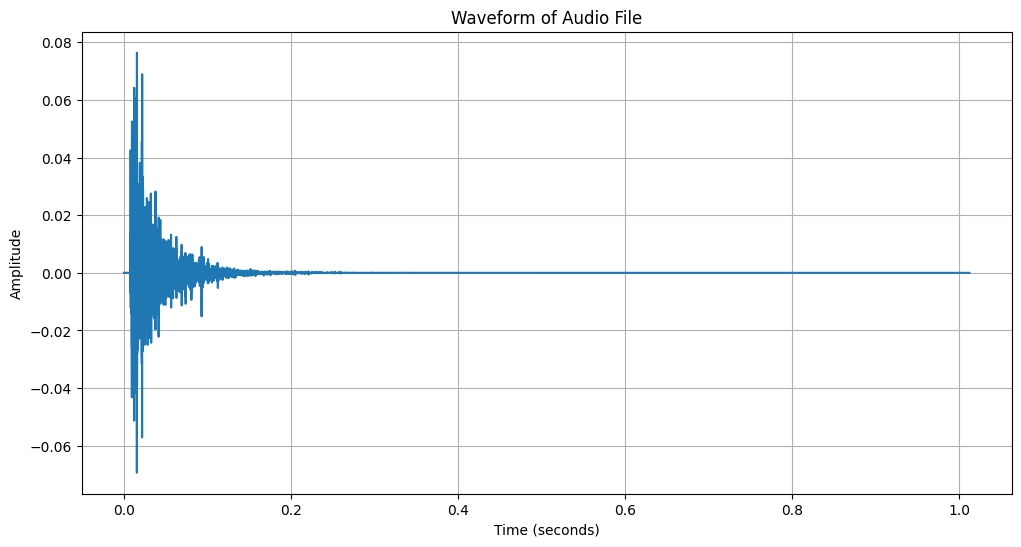

In [17]:
import matplotlib.pyplot as plt
from scipy.io import wavfile

# 加载音频文件
# sample_rate, data = wavfile.read(path)  # 替换为你的音频文件路径
data = audio_one
# 创建时间轴
time = [i / 48000 for i in range(len(data))]

# 绘制波形
plt.figure(figsize=(12, 6))
plt.plot(time, data)
plt.title('Waveform of Audio File')
plt.xlabel('Time (seconds)')
plt.ylabel('Amplitude')
plt.grid()
plt.show()


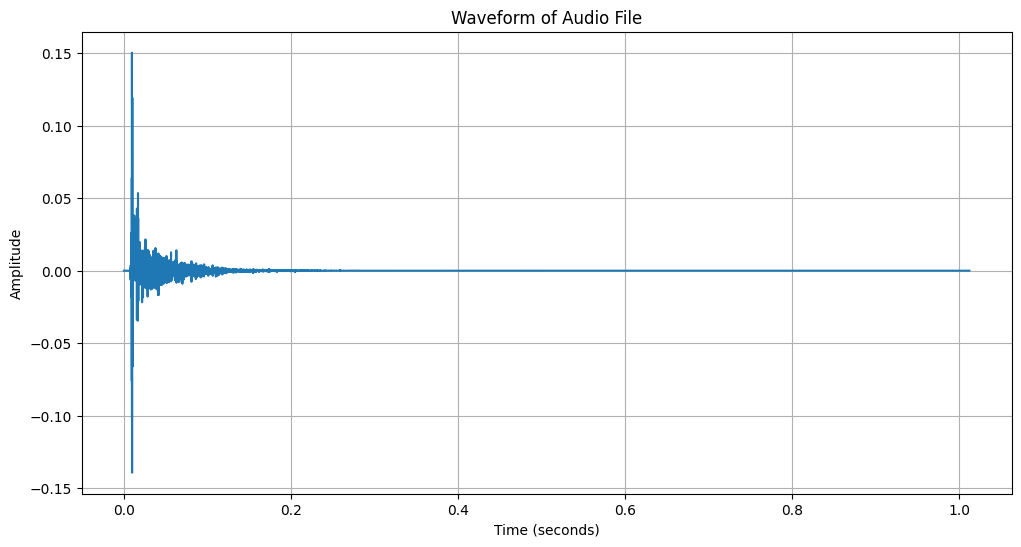

In [18]:
# 加载音频文件
# sample_rate, data = wavfile.read(path)  # 替换为你的音频文件路径
data = audio[1]
# 创建时间轴
time = [i / 48000 for i in range(len(data))]

# 绘制波形
plt.figure(figsize=(12, 6))
plt.plot(time, data)
plt.title('Waveform of Audio File')
plt.xlabel('Time (seconds)')
plt.ylabel('Amplitude')
plt.grid()
plt.show()

In [1]:
import torch

In [2]:
torch.cuda.is_available()

True

In [5]:
a = 13

In [2]:
a / 3

3.3333333333333335

In [3]:
a % 3


1

In [6]:
a // 3


4